In [ ]:
# ANALISIS DE MÉTRICAS DE EXPANSION CLONAL 


In [1]:

# Luego de clustering archivo _clone-pass.tsv se realiza analisis de métricas
# Paquetes y librerías
library(readr)
library(dplyr)
library(ggplot2)
library(viridisLite)
library(tidyr)
library(here)  # para rutas relativas

# actualizar renv despues de la instalación de cada paquete
# renv::snapshot()




Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


here() starts at /Users/catg/Desktop/SOFIAC/Gitsofia/tesisbioinf-sofia/notebooks



In [4]:

# Configuración de archivo

carpeta_archivo <- "../data/output"  
nombre_archivo <- "repertorio_C_insilico_100_seqs_clone-pass.tsv"

# Construir ruta relativa
archivo_clones <- here(carpeta_archivo, nombre_archivo)

# Cargar archivo
clones <- read_tsv(archivo_clones)
head(clones, 5)

Rows: 100 Columns: 50
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr (20): sequence_id, sequence, v_call, d_call, j_call, sequence_alignment,...
dbl (25): junction_length, np1_length, np2_length, v_sequence_start, v_seque...
lgl  (5): rev_comp, productive, stop_codon, vj_in_frame, c_call

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


sequence_id,sequence,rev_comp,productive,v_call,d_call,j_call,sequence_alignment,germline_alignment,junction,...,j_identity,j_support,fwr1,fwr2,fwr3,fwr4,cdr1,cdr2,cdr3,clone_id
<chr>,<chr>,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,...,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
seq82,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTACAGCCAGGGCGGTCCCTGAGACTCTCCTGTACAGCTTCTGGATTCGCTTTTGGTCATTATGCTATGAGCTGGTTCCGTCAGGCTCCAGGGAAGGGGCTGGAGTGGGTAGGTTTCATTAGAAGCAAAGCTTACGGTGGGACAACAGAATACACCGCGTCTGTGAAAGGCAGATTCACCATCTCAAGAGATGGTTCCAAAAGCATCGCCTATCTGCAAATGAACAGCCTGAAAACCGAGGACACAGCCGTGTATTACTGTACTAGAGGCTGGAACGACCACTACTACTACTATGGTATGGACATCTGGGGGCAAGGGACCACGGTCACCGTCTCCTCA,FALSE,TRUE,IGHV3-49*01,"IGHD1-1*01,IGHD1-20*01",IGHJ6*01,GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTACAGCCAGGGCGGTCCCTGAGACTCTCCTGTACAGCTTCTGGATTCGCTTTT............GGTCATTATGCTATGAGCTGGTTCCGTCAGGCTCCAGGGAAGGGGCTGGAGTGGGTAGGTTTCATTAGAAGCAAAGCTTACGGTGGGACAACAGAATACACCGCGTCTGTGAAA...GGCAGATTCACCATCTCAAGAGATGGTTCCAAAAGCATCGCCTATCTGCAAATGAACAGCCTGAAAACCGAGGACACAGCCGTGTATTACTGTACTAGAGGCTGGAACGACCACTACTACTACTATGGTATGGACATCTGGGGGCAAGGGACCACGGTCACCGTCTCCTCA,GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTACAGCCAGGGCGGTCCCTGAGACTCTCCTGTACAGCTTCTGGATTCACCTTT............GGTGATTATGCTATGAGCTGGTTCCGCCAGGCTCCAGGGAAGGGGCTGGAGTGGGTAGGTTTCATTAGAAGCAAAGCTTATGGTGGGACAACAGAATACACCGCGTCTGTGAAA...GGCAGATTCACCATCTCAAGAGATGGTTCCAAAAGCATCGCCTATCTGCAAATGAACAGCCTGAAAACCGAGGACACAGCCGTGTATTACTGTACTAGAGNCTGGAACGACNACTACTACTACTACGGTATGGACGTCTGGGGGCAAGGGACCACGGTCACCGTCTCCTCA,TGTACTAGAGGCTGGAACGACCACTACTACTACTATGGTATGGACATCTGG,...,0.96610,5.60e-26,GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTACAGCCAGGGCGGTCCCTGAGACTCTCCTGTACAGCTTCT,ATGAGCTGGTTCCGTCAGGCTCCAGGGAAGGGGCTGGAGTGGGTAGGTTTC,GAATACACCGCGTCTGTGAAA...GGCAGATTCACCATCTCAAGAGATGGTTCCAAAAGCATCGCCTATCTGCAAATGAACAGCCTGAAAACCGAGGACACAGCCGTGTATTACTGT,TGGGGGCAAGGGACCACGGTCACCGTCTCCTCA,GGATTCGCTTTT............GGTCATTATGCT,ATTAGAAGCAAAGCTTACGGTGGGACAACA,ACTAGAGGCTGGAACGACCACTACTACTACTATGGTATGGACATC,1
seq22,CAGGTTCAGCTGGTGCAGTCTGGAGCTGAGGTGAAGAAGCCTGGGGCCTCAGTGAAGGTCTCCTGCAAGGCTTCTGGTTACACCTTTACCAGCTATGGTATCAGCTGGGTGCGACAGGCCCCTGGACAAGGGCTTGAGTGGATGGGATGGATCAGCGCTTACAATGGTAACATAAACTATGCACCGAGGCGCCAGGGCAGAGTCACCATGACCACAGACACATCCACGAGCACAGCCTACATGGAGCTGAGGAGCCTGAGATCTGACGACACGGCCGTGTATTACTGTGCGAGAGAAGATATAGTGGCTACGATTACAAATGCTTTTGATGTCTGGGGCCAGGGGACGATGGTCACCGTCTCTTCA,FALSE,TRUE,IGHV1-18*01,IGHD5-12*01,IGHJ3*01,CAGGTTCAGCTGGTGCAGTCTGGAGCT...GAGGTGAAGAAGCCTGGGGCCTCAGTGAAGGTCTCCTGCAAGGCTTCTGGTTACACCTTT............ACCAGCTATGGTATCAGCTGGGTGCGACAGGCCCCTGGACAAGGGCTTGAGTGGATGGGATGGATCAGCGCTTAC......AATGGTAACATAAACTATGCACCGAGGCGCCAG...GGCAGAGTCACCATGACCACAGACACATCCACGAGCACAGCCTACATGGAGCTGAGGAGCCTGAGATCTGACGACACGGCCGTGTATTACTGTGCGAGAGAAGATATAGTGGCTACGATTACAAATGCTTTTGATGTCTGGGGCCAGGGGACGATGGTCACCGTCTCTTCA,CAGGTTCAGCTGGTGCAGTCTGGAGCT...GAGGTGAAGAAGCCTGGGGCCTCAGTGAAGGTCTCCTGCAAGGCTTCTGGTTACACCTTT............ACCAGCTATGGTATCAGCTGGGTGCGACAGGCCCCTGGACAAGGGCTTGAGTGGATGGGATGGATCAGCGCTTAC......AATGGTAACACAAACTATGCACAGAAGCTCCAG...GGCAGAGTCACCATGACCACAGACACATCCACGAGCACAGCCTACATGGAGCTGAGGAGCCTGAGATCTGACGACACGGCCGTGTATTACTGTGCGAGAGANGATATAGTGGCTACGATTACNNATGCTTTTGATGTCTGGGGCCAAGGGACAATGGTCACCGTCTCTTCA,TGTGCGAGAGAAGATATAGTGGCTACGATTACAAATGCTTTTGATGTCTGG,...,0.95745,4.85e-19,CAGGTTCAGCTGGTGCAGTCTGGAGCT...GAGGTGAAGAAGCCTGGGGCCTCAGTGAAGGTCTCCTGCAAGGCTTCT,ATCAGCTGGGTGCGACAGGCCCCTGGACAAGGGCTTGAGTGGATGGGATGG,AACTATGCACCGAGGCGCCAG...GGCAGAGTCACCATGACCACAGACACATCCACGAGCACAGCCTACATGGAGCTGAGGAGCCTGAGATCTGACGACACGGCCGTGTATTACTGT,TGGGGCCAGGGGACGATGGTCACCGTCTCTTCA,GGTTACACCTTT............ACCAGCTATGGT,ATCAGCGCTTAC......AATGGTAACATA,GCGAGAGAAGATATAGTGGCTACGATTACAAATGCTTTTGATGTC,2
seq16,CAGGTGCAGCTGGTGCAGTCTGGGGCTGAGGTGAAGAAGCCTGGGGCCTCAGTGAAGGTCTCCTGCAAGGCTTCTGGATACACCTTCACCGACTACTATATGCACTGGGTGCGACAGGCCCCTGGACAAGGGCTTGAGTGGATGGGACGGATCAACCCTAACAGTGGTGGCACGAACTATGCACACAAGTTTCAGGGCAGGGTCACCAGTACCAGGGACACGTCCATCAGCACAGCCTACATGGAGCTGAGCAGGCTGAGATCTGACGACACGGTCGTGTTTTACTGTGCCAGAGGATATTGTAGTAGTACCAGCTGCTATGCTTTTGATG

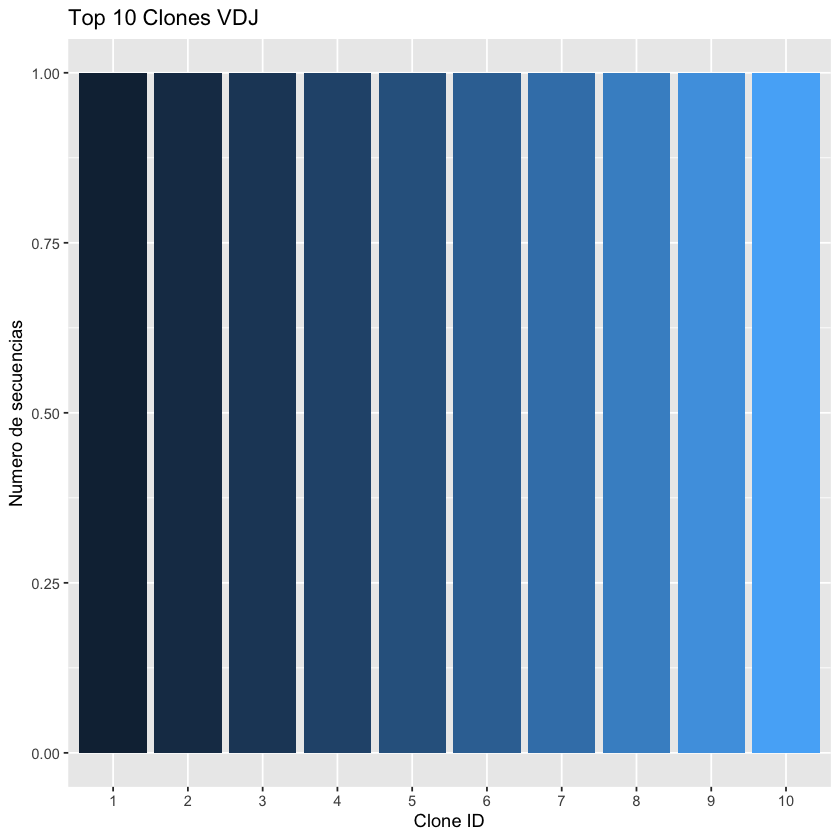

In [5]:
# Tamaño de cada clon

clon_size <- clones %>%
  group_by(clone_id) %>%
  summarise(n_seq = n(), .groups = "drop") %>%
  arrange(desc(n_seq)) %>%
  mutate(freq = n_seq / sum(n_seq))

# Top 10 clones

top10 <- arrange(clon_size, desc(freq)) %>%
  slice_head(n = 10)

ggplot(top10, aes(x = reorder(clone_id, -n_seq), y = n_seq, fill = clone_id)) +
  geom_col() +
  labs(title = "Top 10 Clones VDJ", x = "Clone ID", y = "Numero de secuencias") +
  theme(legend.position = "none")

In [58]:

readr::write_tsv(top10, "../results/expansion/top10_D_10000seqs.tsv")

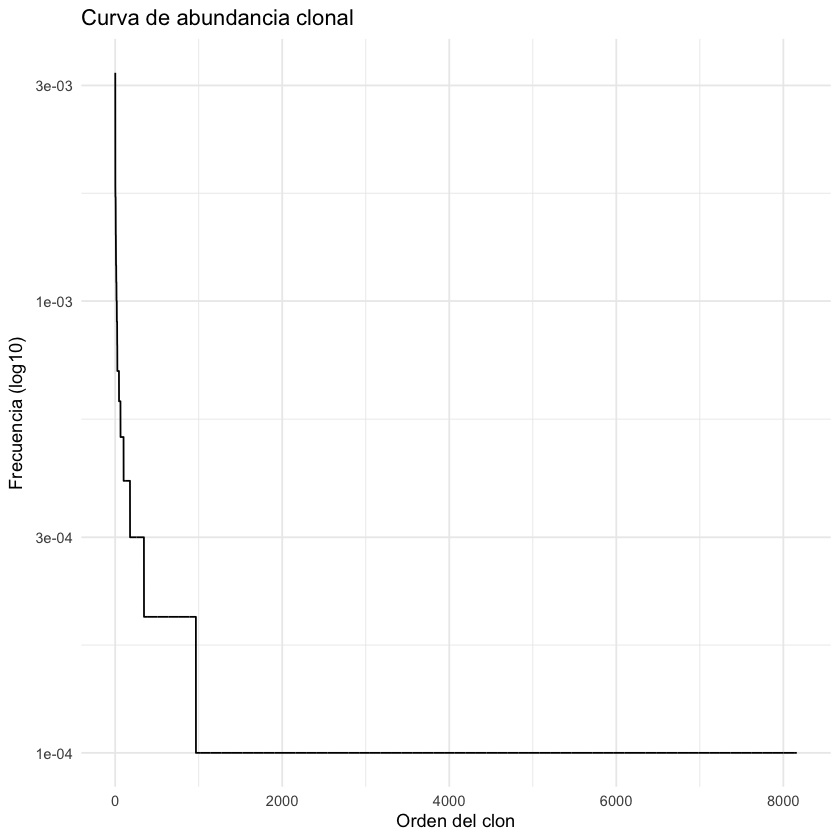

In [59]:

clon_abundancia <- clon_size %>%
  mutate(rank = row_number())

ggplot(clon_abundancia, aes(x = rank, y = freq)) +
  geom_line() +
  scale_y_log10() +
  labs(
    title = "Curva de abundancia clonal", x = "Orden del clon", y = "Frecuencia (log10)") +
  theme_minimal()


In [60]:
readr::write_tsv(clon_abundancia, "../results/expansion/curva_abundancia_D_10000seqs.tsv")

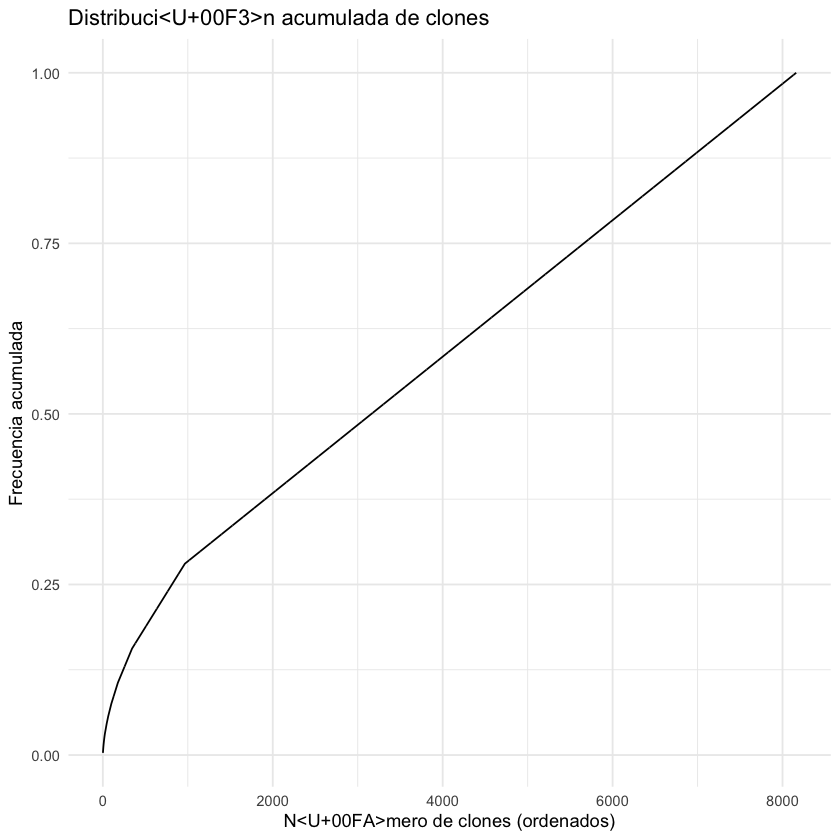

In [61]:
# Distribución acumulada

dist_acumulada <- clon_size %>%
  mutate(cum_freq = cumsum(freq), rank = row_number()) 

ggplot(dist_acumulada, aes(x = rank, y = cum_freq)) +
  geom_line() +
  labs(title = "Distribución acumulada de clones", x = "Número de clones (ordenados)", y = "Frecuencia acumulada") +
  theme_minimal()

In [62]:
readr::write_tsv(dist_acumulada, "../results/expansion/dist_acumulada_D_10000seqs.tsv")